# Constellation Revisit Validation: Sentinel-2

The other validation notebooks compare TAT-C with observations over a single day. This notebook tests TAT-C's predictions over multiple days and multiple satellites: the passes, sample counts, and revisit periods of the three Copernicus [Sentinel-2](https://sentiwiki.copernicus.eu/web/s2-mission) satellites (2A, 2B, and 2C) over 20 days, from 14 September to 3 October 2026, or two of the constellation's 10-day repeat cycles. The Multispectral Instrument (MSI) is modeled as validated in the [Sentinel-2 MSI](ValidatePushbroomMSI.ipynb) notebook. The comparison asks four questions:

1. **Orbit.** How does the accuracy of TAT-C's propagation of public two-line element (TLE) sets degrade over the 20 days before their epochs?
2. **Passes.** Does `collect_multi_observations` predict the passes on which each satellite images points on land?
3. **Revisit.** Do the sample counts and revisit periods from `aggregate_observations` and `reduce_observations` match those observed?
4. **Repeat cycle.** TAT-C computes the access periods for one repeat cycle and repeats them for longer analyses (the `repeat_cycle_for_observation_events` setting). How much does this shortcut change the predictions?

Unlike TAT-C's instrument, which observes whenever a point is in view, MSI follows an acquisition plan: it images land surfaces (and coastal waters, islands, and closed seas) between 56 deg south and 82.8 deg north on the day side of the orbit. Sentinel-2A, which has been succeeded by 2C, images a reduced set of areas. The comparison is therefore limited to points on land and to sunlit passes, and the reduced plan of 2A is assessed separately.

## Reference Data

The [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a) catalog of Sentinel-2 Level 2A products (anonymous access) is searched for every product whose valid data footprint contains a point of interest during the analysis period. Each product is a 110 km tile of one acquisition (datatake); the datatake identifies the satellite and the time at which the acquisition started (the catalog does not record the time each point was imaged). For the orbit test, the GPS ephemeris (in GPS time, 18 s ahead of UTC) of one datastrip per satellite every two days is read from the datastrip metadata.

The points of interest are those of a Fibonacci lattice with a typical spacing of 500 km that lie on land (in the Natural Earth 1:110 million land polygons) between 56 deg south and 82.8 deg north. The first run takes about 15 minutes; reduced data are cached in a local `data/sentinel2` directory.

The satellites are modeled with TLEs from [CelesTrak](https://celestrak.org/) whose epochs (4 October 2026, 11:20 to 12:20 UTC) follow the end of the analysis period by about half a day and its start by about 20 days.

In [1]:
import concurrent.futures
import json
import re
import time
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta, timezone
from pathlib import Path

import cartopy.io.shapereader as shpreader
import numpy as np
import pandas as pd
import requests
from shapely import contains_xy, prepare
from shapely.ops import unary_union

from tatc.generation import generate_points_fibonacci_lattice

DATA_DIR = Path("data") / "sentinel2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 9, 14, tzinfo=timezone.utc)
END = datetime(2026, 10, 4, tzinfo=timezone.utc)
STAC = "https://planetarycomputer.microsoft.com/api/stac/v1/search"
TOKEN = "https://planetarycomputer.microsoft.com/api/sas/v1/token/sentinel-2-l2a"
TLES = {
    "Sentinel-2A": [
        "1 40697U 15028A   26277.51535578  .00000205  00000+0  94862-4 0  9994",
        "2 40697  98.5646 350.7732 0001083  89.0049 271.1258 14.30820153589369",
    ],
    "Sentinel-2B": [
        "1 42063U 17013A   26277.50820593  .00000133  00000+0  67483-4 0  9991",
        "2 42063  98.5691 350.7118 0001149  89.0927 271.0388 14.30818478500277",
    ],
    "Sentinel-2C": [
        "1 60989U 24157A   26277.47326514  .00000038  00000+0  31260-4 0  9993",
        "2 60989  98.5703 350.6835 0001156  81.8213 278.3101 14.30817151108611",
    ],
}
GPS_UTC = 18  # s

land = unary_union(list(shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="land")).geometries()))
prepare(land)
lattice = generate_points_fibonacci_lattice(500e3)
on_land = contains_xy(land, lattice.geometry.x, lattice.geometry.y) & (lattice.geometry.y > -56) & (lattice.geometry.y < 82.8)
points = lattice[on_land].reset_index(drop=True)
points["point_id"] = points.index


def get(url, **kwargs):
    """HTTP GET, retrying transient failures."""
    for attempt in range(5):
        try:
            response = requests.get(url, timeout=120, **kwargs)
            response.raise_for_status()
            return response
        except requests.RequestException:
            if attempt == 4:
                raise


def search(point):
    """Catalog products whose valid data footprint contains a point during the analysis period."""
    body = {
        "collections": ["sentinel-2-l2a"],
        "intersects": {"type": "Point", "coordinates": [point.geometry.x, point.geometry.y]},
        "datetime": f"{START:%Y-%m-%dT%H:%M:%SZ}/{END - timedelta(seconds=1):%Y-%m-%dT%H:%M:%SZ}",
        "limit": 1000,
        "fields": {"include": ["id", "properties.platform", "properties.s2:datatake_id", "properties.s2:datastrip_id", "assets.datastrip-metadata.href"], "exclude": ["links", "geometry"]},
    }
    cache = SEARCH_DIR / f"{point.point_id}.json"
    if cache.exists():
        return json.loads(cache.read_text())
    for attempt in range(8):
        try:
            response = requests.post(STAC, json=body, timeout=300)
            response.raise_for_status()
            features = response.json()["features"]
            break
        except (requests.RequestException, KeyError, ValueError):
            if attempt == 7:
                raise
            # back off (the catalog limits request rates)
            time.sleep(2**attempt)
    rows = [
        {
            "point_id": point.point_id,
            "platform": f["properties"]["platform"],
            "datatake": f["properties"]["s2:datatake_id"],
            "datastrip": f["properties"]["s2:datastrip_id"],
            "datastrip_metadata": f["assets"]["datastrip-metadata"]["href"],
        }
        for f in features
    ]
    cache.write_text(json.dumps(rows))
    return rows


PRODUCTS_FILE = DATA_DIR / f"s2_revisit_products_{START:%Y%m%d}_{END:%Y%m%d}.csv"
SEARCH_DIR = DATA_DIR / "revisit_search"
if not PRODUCTS_FILE.exists():
    SEARCH_DIR.mkdir(exist_ok=True)
    with concurrent.futures.ThreadPoolExecutor(4) as pool:
        pd.DataFrame([r for rows in pool.map(search, points.itertuples()) for r in rows]).to_csv(PRODUCTS_FILE, index=False)
products = pd.read_csv(PRODUCTS_FILE)
# one observed pass per point and datatake (adjacent tiles overlap)
observed = products.drop_duplicates(["point_id", "datatake"]).copy()
observed["datatake_start"] = pd.to_datetime(observed.datatake.str.extract(r"_(\d{8}T\d{6})_")[0], format="%Y%m%dT%H%M%S", utc=True)
pd.Series(
    {
        "points": len(points),
        "points with products": observed.point_id.nunique(),
        "products": len(products),
        "datatakes": observed.datatake.nunique(),
        **{f"observed passes, {p}": int((observed.platform == p).sum()) for p in TLES},
    }
)

points                           687
points with products             687
products                        7232
datatakes                        954
observed passes, Sentinel-2A    1116
observed passes, Sentinel-2B    2068
observed passes, Sentinel-2C    2077
dtype: int64

For the orbit test, the GPS ephemeris of one datastrip per satellite every two days is downloaded and cached.

In [2]:
def strip_namespaces(text):
    return re.sub(r"<(/?)[A-Za-z0-9_]+:", r"<\1", text)


EPHEMERIS_FILE = DATA_DIR / f"s2_revisit_ephemeris_{START:%Y%m%d}_{END:%Y%m%d}.csv"
if not EPHEMERIS_FILE.exists():
    token = get(TOKEN).json()["token"]
    strips = products.drop_duplicates("datastrip").copy()
    strips["day"] = pd.to_datetime(strips.datastrip.str.extract(r"_S(\d{8})T")[0], format="%Y%m%d", utc=True)
    strips = strips[((strips.day - pd.Timestamp(START)).dt.days % 2) == 0].groupby(["platform", "day"]).head(1)

    def read_ephemeris(row):
        root = ET.fromstring(strip_namespaces(get(f"{row.datastrip_metadata}?{token}").text))
        values = lambda p, kind: [float(v) / 1e3 for v in p.find(f"{kind.upper()}_VALUES").text.split()]
        gps = root.findall(".//GPS_Point")
        return pd.DataFrame(
            {
                "platform": row.platform,
                "datastrip": row.datastrip,
                "time": [pd.Timestamp(p.find("GPS_TIME").text, tz="UTC") - pd.Timedelta(seconds=GPS_UTC) for p in gps],
                **{f"position_{a}": [values(p, "position")[i] for p in gps] for i, a in enumerate("xyz")},
                **{f"velocity_{a}": [values(p, "velocity")[i] for p in gps] for i, a in enumerate("xyz")},
            }
        )

    with concurrent.futures.ThreadPoolExecutor(8) as pool:
        pd.concat(pool.map(read_ephemeris, strips.itertuples())).to_csv(EPHEMERIS_FILE, index=False)
ephemeris = pd.read_csv(EPHEMERIS_FILE, parse_dates=["time"])
ephemeris.groupby("platform").agg(datastrips=("datastrip", "nunique"), points=("time", "size"), first=("time", "min"), last=("time", "max"))

,datastrips,points,first,last
platform,,,,
Sentinel-2A,10,5171,2026-09-14 01:30:23+00:00,2026-10-02 02:37:22+00:00
Sentinel-2B,10,4880,2026-09-14 14:42:56+00:00,2026-10-02 22:41:11+00:00
Sentinel-2C,10,5543,2026-09-14 13:56:34+00:00,2026-10-02 15:04:05+00:00


## Setup

MSI is modeled as in the Sentinel-2 MSI notebook: a rectangular `PointedInstrument` spanning cross-track view angles of -10.56 to +10.54 deg in the Earth-fixed velocity frame (the default). It requires the point to be sunlit (`req_target_sunlit`), which excludes the night-side passes. Its along-track field of view (1 deg) only affects the check, at each observation epoch, that the point lies within the view.

In [3]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from skyfield.framelib import itrs

from tatc import config
from tatc.analysis import aggregate_observations, collect_multi_observations, reduce_observations
from tatc.schemas import GeneralPerturbationsOrbit, Point, PointedInstrument, Satellite

PLATFORMS = list(TLES)
msi = PointedInstrument(
    name="MSI",
    field_of_regard=31.1,
    cross_track_field_of_view=21.1,
    along_track_field_of_view=1,
    roll_angle=-0.01,
    is_rectangular=True,
    req_target_sunlit=True,
)
satellites = {name: Satellite(name=name, orbit=GeneralPerturbationsOrbit.from_tle(tle), instruments=[msi]) for name, tle in TLES.items()}
TLE_EPOCH = {name: s.orbit.to_gp_orbit().elements[0].epoch for name, s in satellites.items()}


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
PLATFORM_COLORS = dict(zip(PLATFORMS, [BLUE, ORANGE, AQUA]))
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

## Test 1: Orbit

TAT-C's propagated positions are compared with the GPS ephemeris at 10 s intervals, with residuals decomposed along the velocity, to its right, and radially, as a function of the time before the TLE epoch.

In [4]:
rows1 = []
for platform in PLATFORMS:
    e = ephemeris[ephemeris.platform == platform].iloc[::10]
    position = e[[f"position_{a}" for a in "xyz"]].to_numpy()
    velocity = e[[f"velocity_{a}" for a in "xyz"]].to_numpy()
    predicted = np.array(satellites[platform].orbit.to_gp_orbit().get_orbit_track(e.time.dt.to_pydatetime().tolist()).frame_xyz_and_velocity(itrs)[0].m).T
    offset = predicted - position
    radial = normalize(position)
    along = normalize(velocity - np.sum(velocity * radial, axis=-1, keepdims=True) * radial)
    rows1.append(
        pd.DataFrame(
            {
                "platform": platform,
                "datastrip": e.datastrip.to_numpy(),
                "days before TLE epoch": (TLE_EPOCH[platform] - e.time).dt.total_seconds().to_numpy() / 86400,
                "along-track (km)": np.sum(offset * along, axis=-1) / 1e3,
                "cross-track, right (km)": np.sum(offset * np.cross(along, radial), axis=-1) / 1e3,
                "radial (km)": np.sum(offset * radial, axis=-1) / 1e3,
            }
        )
    )
orbit1 = pd.concat(rows1)
orbit1.groupby(["platform", "datastrip"]).median(numeric_only=True).reset_index().groupby("platform").agg(
    datastrips=("datastrip", "size"),
    days_min=("days before TLE epoch", "min"),
    days_max=("days before TLE epoch", "max"),
    along_max=("along-track (km)", lambda x: x.abs().max()),
    cross_max=("cross-track, right (km)", lambda x: x.abs().max()),
    radial_max=("radial (km)", lambda x: x.abs().max()),
).rename(columns={"days_min": "days before epoch, min", "days_max": "days before epoch, max", "along_max": "along-track, max |x| (km)", "cross_max": "cross-track, max |x| (km)", "radial_max": "radial, max |x| (km)"}).round(2)

C:\Users\pgrogan\AppData\Local\Temp\ipykernel_44940\853932552.py:6: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  predicted = np.array(satellites[platform].orbit.to_gp_orbit().get_orbit_track(e.time.dt.to_pydatetime().tolist()).frame_xyz_and_velocity(itrs)[0].m).T
C:\Users\pgrogan\AppData\Local\Temp\ipykernel_44940\853932552.py:6: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  predicted = np.array(satellites[platform].orbit.to_gp_orbit().get_orbit_track(e.time.dt.to_pydatetime().tolist()).frame_xyz_and_velocity(itrs)[0].m).T
C:\Users\pgrogan\AppData\Local\Temp\ipykernel_44940\853932552.py:6: FutureWa

,datastrips,"days before epoch, min","days before epoch, max","along-track, max |x| (km)","cross-track, max |x| (km)","radial, max |x| (km)"
platform,,,,,,
Sentinel-2A,10,2.41,20.45,28.77,2.25,0.64
Sentinel-2B,10,1.56,19.89,10.54,1.27,0.72
Sentinel-2C,10,1.85,19.89,2.82,0.49,0.81


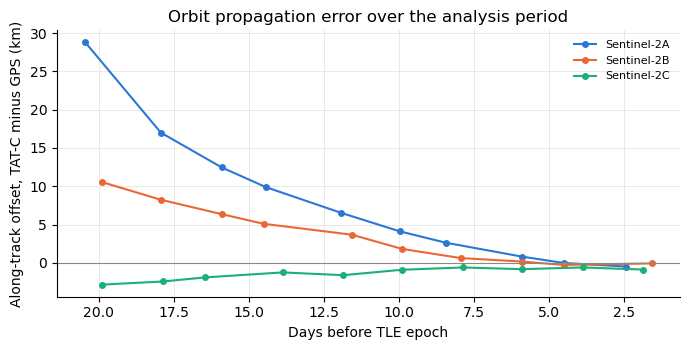

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.6))
strips1 = orbit1.groupby(["platform", "datastrip"]).median(numeric_only=True).reset_index()
for platform in PLATFORMS:
    s = strips1[strips1.platform == platform].sort_values("days before TLE epoch")
    ax.plot(s["days before TLE epoch"], s["along-track (km)"], "o-", ms=4, color=PLATFORM_COLORS[platform], label=platform)
ax.axhline(0, color=GRAY, lw=0.8)
ax.invert_xaxis()
ax.set(xlabel="Days before TLE epoch", ylabel="Along-track offset, TAT-C minus GPS (km)", title="Orbit propagation error over the analysis period")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Propagated backward from their epochs, the TLEs drift along track: after 20 days, TAT-C's Sentinel-2A is 29 km ahead of its GPS position, 2B 11 km ahead, and 2C 3 km behind, while across track and radially they remain within 2.3 and 0.8 km. The along-track offsets grow roughly quadratically with time, as expected of errors in the TLEs' drag terms (2A's TLE has the largest). An along-track offset delays or advances each pass (29 km is about 4 s at MSI's ground speed of 6.6 km/s) but hardly changes which points it covers, so it matters little for the passes and revisit periods tested below.

## Test 2: Passes

`collect_multi_observations` predicts the passes of each satellite over each point, with the default settings (repeat-cycle shortcut enabled). A predicted pass matches an observed pass if it is by the same satellite and its epoch falls within the observed datatake: no earlier than 1 minute before the datatake started and no later than 45 minutes after (the longest day-side datatakes last about 40 minutes, and a satellite's consecutive passes are 100 minutes apart).

In [6]:
def predict(point, constellation=None):
    constellation = list((constellation or satellites).values())
    return collect_multi_observations(Point(id=point.point_id, latitude=point.geometry.y, longitude=point.geometry.x), constellation, START, END, omit_solar=False)


def match(predicted):
    """Match predicted passes (epochs) to observed passes (datatakes) of the same satellite and point."""
    p = predicted[["point_id", "satellite", "epoch", "start", "end", "solar_alt"]].rename(columns={"satellite": "platform"}).sort_values("epoch")
    o = observed[["point_id", "platform", "datatake", "datatake_start"]].sort_values("datatake_start")
    p["point_id"] = p.point_id.astype("int64")
    merged = pd.merge_asof(p, o, left_on="epoch", right_on="datatake_start", by=["point_id", "platform"], direction="backward", tolerance=pd.Timedelta(minutes=46))
    merged = merged[merged.datatake.isna() | (merged.epoch - merged.datatake_start <= pd.Timedelta(minutes=45))]
    hit = merged.datatake.notna()
    observed_only = o[~o.set_index(["point_id", "datatake"]).index.isin(merged[hit].set_index(["point_id", "datatake"]).index)]
    return merged, observed_only


config.get_rc().repeat_cycle_for_observation_events = True
predicted = pd.concat([predict(p) for p in points.itertuples()]).reset_index(drop=True)
merged2, observed_only2 = match(predicted)
rows2 = {}
for platform in PLATFORMS:
    m = merged2[merged2.platform == platform]
    n_observed = int((observed.platform == platform).sum())
    rows2[platform] = {
        "predicted": len(m),
        "observed": n_observed,
        "matched": int(m.datatake.notna().sum()),
        "predicted only": int(m.datatake.isna().sum()),
        "observed only": int((observed_only2.platform == platform).sum()),
        "observed passes matched (%)": 100 * m.datatake.notna().sum() / n_observed,
        "predicted passes acquired (%)": 100 * m.datatake.notna().sum() / len(m),
        "epoch after datatake start, max (min)": (m.epoch - m.datatake_start).max().total_seconds() / 60,
    }
pd.DataFrame(rows2).T.round(1)

,predicted,observed,matched,predicted only,observed only,observed passes matched (%),predicted passes acquired (%),"epoch after datatake start, max (min)"
Sentinel-2A,2259.0,1116.0,1114.0,1145.0,2.0,99.8,49.3,31.1
Sentinel-2B,2256.0,2068.0,2068.0,188.0,0.0,100.0,91.7,33.2
Sentinel-2C,2259.0,2077.0,2077.0,182.0,0.0,100.0,91.9,32.9


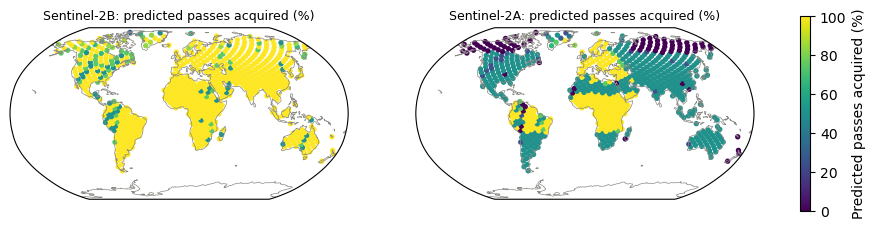

In [7]:
latitude = points.set_index("point_id").geometry.y
fig = plt.figure(figsize=(12, 4.2))
for k, platform in enumerate(["Sentinel-2B", "Sentinel-2A"]):
    ax = fig.add_subplot(1, 2, k + 1, projection=ccrs.Robinson())
    ax.set_global()
    ax.coastlines(color=GRAY, linewidth=0.5)
    m = merged2[merged2.platform == platform]
    acquired = m.groupby("point_id").datatake.apply(lambda d: d.notna().mean())
    xy = points.set_index("point_id").loc[acquired.index].geometry
    sc = ax.scatter(xy.x, xy.y, c=100 * acquired.to_numpy(), s=8, cmap="viridis", vmin=0, vmax=100, transform=ccrs.PlateCarree())
    ax.set_title(f"{platform}: predicted passes acquired (%)", fontsize=9)
fig.colorbar(sc, ax=fig.axes, shrink=0.6, label="Predicted passes acquired (%)")
plt.show()

Over the 20 days, TAT-C predicts every pass on which 2B and 2C imaged a point (4,145 of 4,145) and all but three of 2A's 1,116. Every matched epoch falls within 33 minutes of the datatake start, inside the 45 minute window.

TAT-C also predicts passes that do not appear in the catalog: 8.2% of those of 2B and 2C, and half of those of 2A (map, right). 2A imaged every predicted pass over Africa and parts of South America, about half of those elsewhere, and few in the Arctic: its reduced acquisition plan, which TAT-C does not model.

The predicted passes of 2B and 2C that were not acquired are classified, in order, as:

* **catalog gaps**: no point was acquired by the same satellite within 5 minutes of the predicted epoch, so the products of that part of the orbit are missing from the catalog (or were not acquired at all);
* **low Sun**: the solar elevation at the point is below 10 deg (TAT-C's `req_target_sunlit` only requires it to be above 0 deg);
* **swath edge**: the point's cross-track view angle (from `compute_view_tangents`) is beyond 10.2 deg, outside the swath in which all bands have valid data (290 km); and
* **other**.

In [8]:
from skyfield.api import wgs84

from tatc.utils import compute_view_tangents

geometry = points.set_index("point_id").geometry
nominal = merged2[merged2.platform.isin(["Sentinel-2B", "Sentinel-2C"])].copy()
nominal["acquired"] = nominal.datatake.notna()
nominal["t"] = (nominal.epoch - pd.Timestamp(START)).dt.total_seconds()
acquired_epochs = {platform: np.sort(g.t[g.acquired].to_numpy()) for platform, g in nominal.groupby("platform")}


def cross_track_angle(row):
    track = satellites[row.platform].orbit.to_gp_orbit().get_orbit_track(row.epoch.to_pydatetime())
    _, cross = compute_view_tangents(track, wgs84.latlon(geometry.loc[row.point_id].y, geometry.loc[row.point_id].x), msi.velocity_frame)
    return float(np.degrees(np.arctan(np.ravel(cross)[0])))


def nearest_acquisition(row):
    epochs = acquired_epochs[row.platform]
    i = np.searchsorted(epochs, row.t)
    neighbors = epochs[max(i - 1, 0) : i + 1]
    return np.min(np.abs(neighbors - row.t))


nominal["cross"] = [cross_track_angle(row) for row in nominal.itertuples()]
missed = ~nominal.acquired
nominal["cause"] = "acquired"
gap = missed & np.array([nearest_acquisition(row) > 300 for row in nominal.itertuples()])
nominal.loc[gap, "cause"] = "catalog gap"
nominal.loc[missed & ~gap & (nominal.solar_alt < 10), "cause"] = "low Sun"
nominal.loc[missed & ~gap & (nominal.solar_alt >= 10) & (nominal.cross.abs() > 10.2), "cause"] = "swath edge"
nominal.loc[(nominal.cause == "acquired") & missed, "cause"] = "other"
causes = nominal.groupby(["platform", "cause"]).size().unstack(fill_value=0)[["acquired", "catalog gap", "low Sun", "swath edge", "other"]]
causes["acquired, excluding catalog gaps (%)"] = 100 * causes.acquired / (causes.sum(axis=1) - causes["catalog gap"])
pd.concat(
    [
        causes,
        pd.DataFrame(
            {
                "acquired passes, solar elevation, min (deg)": nominal[nominal.acquired].groupby("platform").solar_alt.min(),
                "acquired passes, |cross-track angle|, max (deg)": nominal[nominal.acquired].groupby("platform").cross.apply(lambda x: x.abs().max()),
                "swath edge passes acquired (%)": nominal[nominal.cross.abs() > 10.2].groupby("platform").apply(lambda g: 100 * g.acquired.sum() / (g.cause != "catalog gap").sum()),
            }
        ),
    ],
    axis=1,
).round(1)

C:\Users\pgrogan\AppData\Local\Temp\ipykernel_44940\3687684623.py:13: UserWarning: Discarding nonzero nanoseconds in conversion.
  track = satellites[row.platform].orbit.to_gp_orbit().get_orbit_track(row.epoch.to_pydatetime())


C:\Users\pgrogan\AppData\Local\Temp\ipykernel_44940\3687684623.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "swath edge passes acquired (%)": nominal[nominal.cross.abs() > 10.2].groupby("platform").apply(lambda g: 100 * g.acquired.sum() / (g.cause != "catalog gap").sum()),


,acquired,catalog gap,low Sun,swath edge,other,"acquired, excluding catalog gaps (%)","acquired passes, solar elevation, min (deg)","acquired passes, |cross-track angle|, max (deg)",swath edge passes acquired (%)
platform,,,,,,,,,
Sentinel-2B,2068,110,28,12,38,96.4,5.5,10.5,76.8
Sentinel-2C,2077,94,47,11,30,95.9,8.3,10.5,76.7


Of the predicted passes of 2B and 2C that were not acquired:

* **Catalog gaps** account for more than half (204 of 370): no product of that satellite exists for minutes around the predicted epoch. They include several consecutive orbits on 27 and 28 September and the last hours of 3 October, whose products had not yet been published. Excluding them, 96% of the predicted passes were acquired.
* **Low Sun** accounts for 75, mostly at points north of 78 deg in late September. No pass with a solar elevation below 5.5 deg was acquired, while TAT-C's `req_target_sunlit` admits any positive solar elevation.
* **Swath edge** accounts for 23: TAT-C's swath spans the red band's view angles (296 km), slightly wider than the swath in which all bands have valid data. About three quarters of the predicted passes within 0.35 deg of the swath edges were acquired.
* The remaining 68 (1.5% of the predicted passes) are isolated passes at points across all latitudes, likely individual products missing from the catalog or areas excluded by the acquisition plan.

The predictions are repeated with a minimum target solar elevation angle of 5 deg (`min_target_solar_elevation`) in place of the sunlit-target requirement, just below the lowest solar elevation of any acquired pass.

In [9]:
msi_daylight = PointedInstrument(**{**msi.model_dump(), "req_target_sunlit": None, "min_target_solar_elevation": 5})
daylight = {name: s.model_copy(update={"instruments": [msi_daylight]}) for name, s in satellites.items()}
predicted5 = pd.concat([predict(p, daylight) for p in points.itertuples()]).reset_index(drop=True)
merged5, observed_only5 = match(predicted5)
key = lambda frame: frame.assign(point_id=frame.point_id.astype("int64")).set_index(["point_id", "platform", "epoch"]).index
nominal5 = nominal.set_index(["point_id", "platform", "epoch"]).loc[nominal.set_index(["point_id", "platform", "epoch"]).index.isin(key(merged5))]
causes5 = nominal5.groupby(["platform", "cause"]).size().unstack(fill_value=0).reindex(columns=["acquired", "catalog gap", "low Sun", "swath edge", "other"], fill_value=0)
causes5["acquired, excluding catalog gaps (%)"] = 100 * causes5.acquired / (causes5.sum(axis=1) - causes5["catalog gap"])
causes5["predicted passes removed"] = nominal.groupby("platform").size() - nominal5.groupby("platform").size()
causes5["observed only"] = observed_only5[observed_only5.platform.isin(causes5.index)].groupby("platform").size().reindex(causes5.index, fill_value=0)
causes5.round(1)

cause,acquired,catalog gap,low Sun,swath edge,other,"acquired, excluding catalog gaps (%)",predicted passes removed,observed only
platform,,,,,,,,
Sentinel-2B,2068,85,7,12,38,97.3,46,0
Sentinel-2C,2077,65,28,11,30,96.8,48,0


The minimum solar elevation removes 94 predicted passes of 2B and 2C, none of which was acquired (many fell in catalog gaps as well), and leaves every acquired pass predicted. The low-Sun misses fall from 75 to 35, all at solar elevations between 5 and 10 deg, and 97% of the remaining predicted passes outside catalog gaps were acquired. The remaining low-Sun misses suggest that Sentinel-2's acquisition plan is not a sharp solar elevation threshold: the lowest acquired solar elevations are 5.5 deg for 2B and 8.3 deg for 2C.

## Test 3: Revisit

For each point, the observed passes (at the datatake start times) and the predicted passes (at their epochs, excluding those in catalog gaps) are aggregated with `aggregate_observations` and reduced with `reduce_observations` to a number of samples and a mean revisit period, for the constellation of 2B and 2C (whose acquisition plans include every pass over land) and for all three satellites. The maximum revisit (longest gap between consecutive passes) is also computed. Because the datatake start precedes the imaging time by up to 40 minutes, revisit periods are compared in days.

In [10]:
def as_observations(frame, time_column, satellite_column):
    """A data frame of instantaneous observations, as accepted by aggregate_observations."""
    t = frame[time_column]
    return pd.DataFrame(
        {"point_id": frame.point_id.astype("int64").to_numpy(), "geometry": points.set_index("point_id").geometry.loc[frame.point_id].to_numpy(),
         "satellite": frame[satellite_column].to_numpy(), "instrument": "MSI", "start": t.to_numpy(), "epoch": t.to_numpy(), "end": t.to_numpy()}
    )


def revisit_statistics(frame):
    import geopandas as gpd

    aggregated = aggregate_observations(gpd.GeoDataFrame(frame, crs="EPSG:4326"))
    reduced = reduce_observations(aggregated).set_index("point_id")
    reduced["max revisit"] = aggregated.groupby("point_id").revisit.max()
    return reduced[["samples", "revisit", "max revisit"]].reindex(points.point_id)


gaps = nominal[nominal.cause == "catalog gap"].set_index(["point_id", "platform", "epoch"]).index
in_gap = predicted.assign(point_id=predicted.point_id.astype("int64")).set_index(["point_id", "satellite", "epoch"]).index.isin(gaps)
in_gap5 = predicted5.assign(point_id=predicted5.point_id.astype("int64")).set_index(["point_id", "satellite", "epoch"]).index.isin(gaps)
rows3, stats3 = {}, {}
for label, members, frame, frame_in_gap in [
    ("2B + 2C", ["Sentinel-2B", "Sentinel-2C"], predicted, in_gap),
    ("2B + 2C, solar elevation >= 5 deg", ["Sentinel-2B", "Sentinel-2C"], predicted5, in_gap5),
    ("2A + 2B + 2C", PLATFORMS, predicted, in_gap),
]:
    o = revisit_statistics(as_observations(observed[observed.platform.isin(members)], "datatake_start", "platform"))
    p = revisit_statistics(as_observations(frame[frame.satellite.isin(members) & ~frame_in_gap], "epoch", "satellite"))
    stats3[label] = (o, p)
    days = lambda x: x.dt.total_seconds() / 86400
    rows3[label] = {
        "points observed": int(o.samples.notna().sum()),
        "samples per point, observed (median)": o.samples.median(),
        "samples per point, predicted (median)": p.samples.median(),
        "points with equal samples (%)": 100 * np.mean(o.samples.fillna(0) == p.samples.fillna(0)),
        "samples, predicted minus observed (mean)": np.mean(p.samples.fillna(0) - o.samples.fillna(0)),
        "mean revisit, observed (median, days)": days(o.revisit).median(),
        "mean revisit, predicted (median, days)": days(p.revisit).median(),
        "mean revisit difference, p95 |x| (days)": np.nanpercentile(np.abs(days(p.revisit) - days(o.revisit)), 95),
        "max revisit, observed (median, days)": days(o["max revisit"]).median(),
        "max revisit, predicted (median, days)": days(p["max revisit"]).median(),
    }
pd.DataFrame(rows3).round(2)

,2B + 2C,"2B + 2C, solar elevation >= 5 deg",2A + 2B + 2C
points observed,687.00,687.00,687.00
"samples per point, observed (median)",4.00,4.00,6.00
"samples per point, predicted (median)",4.00,4.00,6.00
points with equal samples (%),88.65,88.65,23.87
"samples, predicted minus observed (mean)",0.24,0.18,1.91
"mean revisit, observed (median, days)",5.00,5.00,3.00
"mean revisit, predicted (median, days)",5.00,5.00,3.00
"mean revisit difference, p95 |x| (days)",0.40,0.40,1.25
"max revisit, observed (median, days)",5.00,5.00,5.00
"max revisit, predicted (median, days)",5.00,5.00,5.00


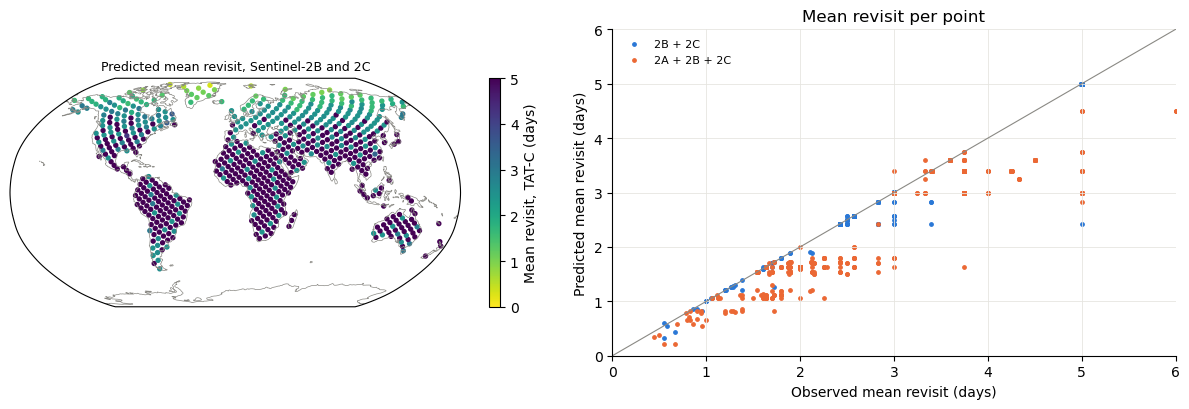

In [11]:
fig = plt.figure(figsize=(12, 4.2))
o, p = stats3["2B + 2C"]
ax = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines(color=GRAY, linewidth=0.5)
xy = points.set_index("point_id").geometry
sc = ax.scatter(xy.x, xy.y, c=(p.revisit.dt.total_seconds() / 86400).to_numpy(), s=8, cmap="viridis_r", vmin=0, vmax=5, transform=ccrs.PlateCarree())
fig.colorbar(sc, ax=ax, shrink=0.7, label="Mean revisit, TAT-C (days)")
ax.set_title("Predicted mean revisit, Sentinel-2B and 2C", fontsize=9)
ax2 = fig.add_subplot(1, 2, 2)
for label, color in [("2B + 2C", BLUE), ("2A + 2B + 2C", ORANGE)]:
    o, p = stats3[label]
    ax2.scatter(o.revisit.dt.total_seconds() / 86400, p.revisit.dt.total_seconds() / 86400, s=6, color=color, label=label)
ax2.plot([0, 6], [0, 6], color=GRAY, lw=0.8)
ax2.set(xlim=(0, 6), ylim=(0, 6), xlabel="Observed mean revisit (days)", ylabel="Predicted mean revisit (days)", title="Mean revisit per point")
ax2.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

For the constellation of 2B and 2C, whose acquisition plans include every pass over land, TAT-C reproduces the sample counts and revisit periods. The median point is sampled 4 times in 20 days, with a mean revisit of 5.0 days, both observed and predicted; 89% of points have exactly the observed number of samples, and the predicted mean revisit is within 0.4 days of the observed at 95% of points. The few extra predicted samples (0.24 per point on average, or 0.18 with the 5 deg minimum solar elevation) are the low-Sun, swath edge, and other passes above. The map shows the 5 day revisit at low and middle latitudes and shorter revisits toward the poles, where adjacent swaths overlap.

Including 2A, the median point is sampled 6 times with a mean revisit of 3.0 days, both observed and predicted, but only 24% of points have the observed number of samples: TAT-C, assuming every pass is acquired, predicts 1.9 more samples per point on average and shorter revisits wherever 2A acquires only some passes. Revisit predictions are only as good as the assumed acquisition plan.

## Test 4: Repeat Cycle

The predictions are repeated with the repeat-cycle shortcut disabled, so that the access periods are computed by propagating each TLE over the whole analysis period, and the epochs of the passes predicted both ways are compared.

In [12]:
config.get_rc().repeat_cycle_for_observation_events = False
direct = pd.concat([predict(p) for p in points.itertuples()]).reset_index(drop=True)
config.get_rc().repeat_cycle_for_observation_events = True
merged4, observed_only4 = match(direct)
pair = pd.merge_asof(
    predicted.assign(point_id=predicted.point_id.astype("int64")).sort_values("epoch")[["point_id", "satellite", "epoch"]],
    direct.assign(point_id=direct.point_id.astype("int64"), epoch_direct=direct.epoch).sort_values("epoch")[["point_id", "satellite", "epoch", "epoch_direct"]],
    on="epoch", by=["point_id", "satellite"], direction="nearest", tolerance=pd.Timedelta(minutes=10),
)
pair = pair.merge(
    predicted.assign(point_id=predicted.point_id.astype("int64"))[["point_id", "satellite", "epoch", "start", "end"]], on=["point_id", "satellite", "epoch"]
).merge(
    direct.assign(point_id=direct.point_id.astype("int64"))[["point_id", "satellite", "epoch", "start", "end"]].rename(columns={"epoch": "epoch_direct", "start": "start_direct", "end": "end_direct"}),
    on=["point_id", "satellite", "epoch_direct"], how="left",
)
pair["difference (s)"] = (pair.epoch - pair.epoch_direct).dt.total_seconds()
pair["start difference (s)"] = (pair.start - pair.start_direct).dt.total_seconds()
pair["end difference (s)"] = (pair.end - pair.end_direct).dt.total_seconds()
pair["day"] = (pair.epoch - pd.Timestamp(START)).dt.total_seconds() / 86400
rows4 = {
    "passes, repeat-cycle shortcut": len(predicted),
    "passes, direct propagation": len(direct),
    "passes predicted only one way": int(pair.epoch_direct.isna().sum()) + len(direct) - int(pair.epoch_direct.notna().sum()),
    "epoch difference, first cycle, p95 |x| (s)": np.percentile(np.abs(pair["difference (s)"][pair.day < 10].dropna()), 95),
    "epoch difference, second cycle, p95 |x| (s)": np.percentile(np.abs(pair["difference (s)"][pair.day >= 10].dropna()), 95),
    "access start difference, first cycle, p95 |x| (s)": np.percentile(np.abs(pair["start difference (s)"][pair.day < 10].dropna()), 95),
    "access start difference, second cycle, p95 |x| (s)": np.percentile(np.abs(pair["start difference (s)"][pair.day >= 10].dropna()), 95),
    "access end difference, second cycle, p95 |x| (s)": np.percentile(np.abs(pair["end difference (s)"][pair.day >= 10].dropna()), 95),
    "matched observed passes, shortcut": int(merged2.datatake.notna().sum()),
    "matched observed passes, direct": int(merged4.datatake.notna().sum()),
}
pd.Series(rows4).round(2)

passes, repeat-cycle shortcut                         6774.00
passes, direct propagation                            6780.00
passes predicted only one way                           12.00
epoch difference, first cycle, p95 |x| (s)               0.00
epoch difference, second cycle, p95 |x| (s)              2.73
access start difference, first cycle, p95 |x| (s)        0.00
access start difference, second cycle, p95 |x| (s)       2.76
access end difference, second cycle, p95 |x| (s)         2.75
matched observed passes, shortcut                     5259.00
matched observed passes, direct                       5260.00
dtype: float64

With the repeat-cycle shortcut (and a detected repeat cycle of exactly 10 days, a whole number of mean solar days for this sun-synchronous orbit), `collect_observations` models an orbit maintained on its repeat ground track: within each repeated cycle, the access periods, epochs, and fields of view are evaluated with the satellite's Earth-fixed state in the first cycle. In the first cycle, the predictions are identical to direct propagation of the TLEs. In the second, the epochs differ by up to 2.7 s (95th percentile), the difference between the maintained orbit and the TLEs propagated for another 10 days, and 12 of the 6,780 passes (at the edges of the field of regard) are predicted only one way; both predict nearly the same observed passes (5,259 and 5,260). The difference grows with each cycle: over months, the maintained orbit represents an operational mission, whose orbit is kept on its ground track, while direct propagation of a single TLE drifts.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (CelesTrak TLE vs. GPS ephemeris) | along-track offset after 20 days: 29 km (2A), 11 km (2B), 3 km (2C); across track and radially within 2.3 km |
| 2. Passes (`collect_multi_observations`) | all observed passes of 2B and 2C predicted (and all but three of 2A); 96% of the predicted passes of 2B and 2C acquired, excluding catalog gaps (97% with a 5 deg minimum solar elevation); misses at low Sun, at the swath edges, and isolated; 2A's reduced plan acquires half of its predicted passes |
| 3. Revisit (`aggregate_observations`, `reduce_observations`) | 2B and 2C: median 4 samples and 5.0 day mean revisit, observed and predicted; samples equal at 89% of points; mean revisit within 0.4 days at 95% of points |
| 4. Repeat cycle | maintained orbit: identical to direct propagation in the first cycle; epochs differ by 2.7 s (95th percentile) in the second, with nearly the same observed passes matched |

**Revisit.** Over two repeat cycles, a single-view `PointedInstrument` per satellite with a sunlit-target requirement (or a minimum solar elevation), propagated from public TLEs up to 20 days old, predicts every observed pass of the Sentinel-2 constellation and reproduces the sample counts and revisit periods of the satellites that image every pass over land. The remaining differences come from what TAT-C does not model, the acquisition plan (2A's reduced plan, and acquisitions at low solar elevations), and from data missing from the reference catalog.

**Illumination and repeat cycles.** A minimum target solar elevation (`min_target_solar_elevation`) represents the illumination constraint of an optical imager more closely than the sunlit-target requirement, removing passes that would not be acquired without removing any that were. The repeat-cycle shortcut (`repeat_cycle_for_observation_events`) both speeds up long analyses and models an orbit maintained on its repeat ground track; disabling it propagates the orbit's elements directly, which over months drifts from an operational orbit.